# Tanager Mangrove Mapping - 03 Transferability

| | |
|---|---|
| **Authors**     | Muhammad Wahyu Ramadhan, Athar Abdurrahman B., Diniyarti |
| **Competition** | Planet Tanager Open Data Competition 2026 |
| **Topic**       | Transferable Mangrove Extent Mapping Using Adaptive Spectral Thresholds |
| **Date**        | June 2026 |

---

**Scope:** Apply pipeline trained on Sangatta to Gujarat, El Salvador, Belize, Australia. Per-scene adaptive threshold recalibration - no retraining. Accuracy evaluation against GMW v3.

## 0. Environment Setup

In [3]:
!pip install scikit-learn geopandas rasterio matplotlib joblib xgboost


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import sys
import json
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

# ============================================================
# Project root
# ============================================================
# Google Colab (Google Drive mounted)
ROOT        = Path('/content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping')

# Local (uncomment if running locally)
#ROOT = Path('..').resolve()

DATA_RAW    = ROOT / 'data' / 'raw'
DATA_PROC   = ROOT / 'data' / 'processed'
DATA_GMW    = ROOT / 'data' / 'gmw_v3'
OUT_MODELS  = ROOT / 'outputs' / 'models'
OUT_RESULTS = ROOT / 'outputs' / 'results'
OUT_FIGURES = ROOT / 'outputs' / 'figures'

for d in (OUT_MODELS, OUT_RESULTS, OUT_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))

# ============================================================
# Reload src modules during development
# ============================================================
import src.preprocessing   as _pre
import src.classification  as _cls
import src.evaluation      as _eval
import src.transferability as _tr
import src.spatial_viz     as _sviz
importlib.reload(_pre)
importlib.reload(_cls)
importlib.reload(_eval)
importlib.reload(_tr)
importlib.reload(_sviz)
from src.classification  import load_model
from src.evaluation      import plot_confusion_matrix, plot_agreement_map
from src.transferability import run_all_transfer_sites, run_transfer_scene, TRANSFER_SITES, SITE_LABELS
from src.spatial_viz     import reproject_raster_to_4326, reproject_array_to_4326, format_map_axes

# ============================================================
# Scene IDs (same dict as 01 and 02)
# ============================================================
SCENES = {
    'sangatta'   : '20250302_030003_92_4001',
    'gujarat'    : '20250311_061550_53_4001',
    'elsalvador' : '20250223_165546_32_4001',
    'belize'     : '20250824_171853_67_4001',
    'belize2'    : '20250824_171857_84_4001',
    'australia'  : '20250608_014315_58_4001',
}

TRAIN_SITE     = 'sangatta'
TRAIN_SCENE_ID = SCENES[TRAIN_SITE]

print(f'ROOT           : {ROOT}')
print(f'Training site  : {TRAIN_SITE} ({TRAIN_SCENE_ID})')
print(f'Transfer sites : {list(TRANSFER_SITES.keys())}')

ROOT           : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping
Training site  : sangatta (20250302_030003_92_4001)
Transfer sites : ['gujarat', 'elsalvador', 'belize', 'belize2', 'australia']


## 1. Load Trained Model

In [6]:
# ============================================================
# Load trained models from Sangatta
# ============================================================
RUN_XGB = True

xgb_model_path = OUT_MODELS / f'xgb_tuned_{TRAIN_SITE}_{TRAIN_SCENE_ID}.joblib'

models_to_run = {}
if RUN_XGB:
    models_to_run['XGBoost'] = str(xgb_model_path)
    print(f'XGB model : {xgb_model_path.name}')

print(f'Features  : 9 (8 indices + REIP)')


XGB model : xgb_tuned_sangatta_20250302_030003_92_4001.joblib
Features  : 9 (8 indices + REIP)


## 2. Transfer Pipeline - All Sites

Per-scene pipeline (no retraining):
1. Load 6-band GeoTIFF
2. Compute spectral indices
3. Adaptive coastal candidate mask (Otsu)
4. Adaptive threshold per scene (MVI force_otsu)
5. Load REIP raster + resample to indices grid
6. Predict extent with Sangatta RF model
7. Evaluate against GMW v3 (if available)


In [7]:
# ============================================================
# Run transfer pipeline for each selected model
# Each model called once per site -- no retraining
# Results stored per model key for comparison
# ============================================================
import time

summary_by_model = {}

for model_key, model_path in models_to_run.items():
    print(f'\n{"="*60}')
    print(f'  Running transfer : {model_key}')
    print(f'{"="*60}')
    t0 = time.time()
    df = run_all_transfer_sites(
        processed_dir = str(DATA_PROC),
        model_path    = model_path,
        results_dir   = str(OUT_RESULTS),
        gmw_dir       = str(DATA_GMW),
    )
    df['model'] = model_key
    elapsed = time.time() - t0
    print(f'  Duration : {elapsed/60:.1f} min ({elapsed:.0f} s)')
    summary_by_model[model_key] = df
    df.to_csv(OUT_RESULTS / f'transferability_summary_{model_key.lower()}.csv', index=False)
    print(f'  Saved    : transferability_summary_{model_key.lower()}.csv')



  Running transfer : XGBoost

  Transfer site  : Gujarat, India  (20250311_061550_53_4001)


  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Coastal candidate mask:
  water_t  (MNDWI)    : 0.1320
  veg_t    (SAVI)     : 0.0608
  buffer_t (otsu)     : 21.5 px (~644 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 137,506 (21.6%)

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250311_061550_53_4001
  NDVI    : threshold = 0.2722  [bimodal]
  MNDWI   : threshold = -0.3404  [bimodal]
  NDMI    : threshold = -0.066

/usr/lib/python3.12/pickle.py:1760: UserWarning: [03:05:30] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


  Spatial constraint applied (outside candidate zone -> 0)
  Mangrove extent: 90 px


  Extent saved   : extent_mangrove_gujarat_20250311_061550_53_4001.tif
  Mangrove area  : 8.1 ha  (90 px)
  GMW v3 rasterized : 3,849 mangrove px (0.61%)

  Evaluation vs GMW v3 -- RF (Gujarat, India)
  domain        : candidate zone
  pixels        : 137,506
  -----------------------------------
  Overall Acc   : 0.9807
  Cohen kappa   : -0.0013
  Precision     : 0.0000  (of predicted mangrove, how many correct)
  Recall        : 0.0000  (of true mangrove, how many found)
  F1 (mangrove) : 0.0000
  IoU (mangrove): 0.0000
  -----------------------------------
  Confusion matrix [rows=true, cols=pred]:
                 pred_non   pred_mang
  true_non        134,851         90
  true_mang         2,565          0

  Transfer site  : El Salvador  (20250223_165546_32_4001)


...

  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 16N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Coastal candidate mask:
  water_t  (MNDWI)    : -0.0877
  veg_t    (SAVI)     : 0.2676
  buffer_t (otsu)     : 33.6 px (~1009 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 105,739 (20.7%)

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250824_171857_84_4001
  NDVI    : threshold = 0.7958  [bimodal]
  MNDWI   : threshold = -0.3788  [bimodal]
  NDMI    : threshold = 0.3

  Spatial constraint applied (outside candidate zone -> 0)
  Mangrove extent: 17,976 px


  Extent saved   : extent_mangrove_belize2_20250824_171857_84_4001.tif
  Mangrove area  : 1,617.8 ha  (17,976 px)
  GMW v3 rasterized : 8,005 mangrove px (1.56%)

  Evaluation vs GMW v3 -- RF (Belize 2)
  domain        : candidate zone
  pixels        : 105,739
  -----------------------------------
  Overall Acc   : 0.8492
  Cohen kappa   : 0.2358
  Precision     : 0.1782  (of predicted mangrove, how many correct)
  Recall        : 0.7320  (of true mangrove, how many found)
  F1 (mangrove) : 0.2867
  IoU (mangrove): 0.1673
  -----------------------------------
  Confusion matrix [rows=true, cols=pred]:
                 pred_non   pred_mang
  true_non         86,590     14,772
  true_mang         1,173      3,204

  Transfer site  : Australia  (20250608_014315_58_4001)


  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 53S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",135],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Coastal candidate mask:
  water_t  (MNDWI)    : 0.2294
  veg_t    (SAVI)     : 0.1543
  buffer_t (otsu)     : 65.1 px (~1953 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 122,740 (20.1%)

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250608_014315_58_4001
  NDVI    : threshold = 0.4863  [bimodal]
  MNDWI   : threshold = -0.2572  [bimodal]
  NDMI    : threshold

  Spatial constraint applied (outside candidate zone -> 0)
  Mangrove extent: 47,319 px
  Extent saved   : extent_mangrove_australia_20250608_014315_58_4001.tif
  Mangrove area  : 4,258.7 ha  (47,319 px)
  GMW v3 rasterized : 64,478 mangrove px (10.56%)

  Evaluation vs GMW v3 -- RF (Australia)
  domain        : candidate zone
  pixels        : 122,740
  -----------------------------------
  Overall Acc   : 0.8171
  Cohen kappa   : 0.6268
  Precision     : 0.8548  (of predicted mangrove, how many correct)
  Recall        : 0.7220  (of true mangrove, how many found)
  F1 (mangrove) : 0.7828
  IoU (mangrove): 0.6431
  -----------------------------------
  Confusion matrix [rows=true, cols=pred]:
                 pred_non   pred_mang
  true_non         59,845      6,870
  true_mang        15,576     40,449

  Transfer summary:
          site  area_ha  n_mangrove_px     kappa       f1   recall
Gujarat, India     8.10             90 -0.001266 0.000000 0.000000
   El Salvador  5411.16       

## 3. Accuracy Summary vs GMW v3

Metrics computed per site within the coastal candidate zone (same domain as training evaluation on Sangatta).


In [8]:
# ============================================================
# Accuracy comparison table: XGBoost per transfer site
# Metrics: Kappa, Precision, Recall, F1, IoU
# Sangatta (train) included as baseline row
# ============================================================
import pandas as pd

metric_cols = ['kappa', 'precision', 'recall', 'f1', 'iou']

# Sangatta baseline - read from model_comparison CSV (XGBoost Tuned row)
sangatta_rows = []
for model_key in models_to_run:
    p = OUT_RESULTS / f'model_comparison_{TRAIN_SITE}_{TRAIN_SCENE_ID}.csv'
    if p.exists():
        df_s = pd.read_csv(p)
        # Normalise column names to lowercase for uniform access
        df_s.columns = df_s.columns.str.lower().str.replace('f1_mangrove', 'f1')
        row = {'site': 'Sangatta (train)', 'model': model_key}
        for col in metric_cols:
            row[col] = df_s[col].values[0] if col in df_s.columns else None
        sangatta_rows.append(row)

# Transfer site metrics
transfer_rows = []
for model_key, df in summary_by_model.items():
    for _, r in df.iterrows():
        row = {'site': r['site'], 'model': model_key}
        for col in metric_cols:
            row[col] = r.get(col, None)
        transfer_rows.append(row)

all_rows = sangatta_rows + transfer_rows
acc_df   = pd.DataFrame(all_rows)

# Pivot: site sebagai baris, model+metric sebagai kolom
pivot = acc_df.pivot_table(
    index='site',
    columns='model',
    values=metric_cols,
    aggfunc='first',
)
pivot.columns = [f'{metric}_{model}' for metric, model in pivot.columns]
pivot = pivot.reset_index()

# Urutkan kolom: site, lalu per-metric RF vs XGBoost berdampingan
ordered_cols = ['site']
for col in metric_cols:
    for model_key in models_to_run:
        c = f'{col}_{model_key}'
        if c in pivot.columns:
            ordered_cols.append(c)
pivot = pivot[ordered_cols]

# Format 4 desimal
for col in pivot.columns[1:]:
    pivot[col] = pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else '-')

print('\n  Transferability accuracy -- XGBoost per site:')
print(pivot.to_string(index=False))
pivot.to_csv(OUT_RESULTS / 'transferability_accuracy_comparison.csv', index=False)
print('\n  Saved : transferability_accuracy_comparison.csv')


  Transferability accuracy -- XGBoost per site:
            site kappa_XGBoost precision_XGBoost recall_XGBoost f1_XGBoost iou_XGBoost
       Australia        0.6268            0.8548         0.7220     0.7828      0.6431
        Belize 1        0.5051            0.4209         0.8067     0.5532      0.3823
        Belize 2        0.2358            0.1782         0.7320     0.2867      0.1673
     El Salvador        0.5787            0.9429         0.7342     0.8256      0.7030
  Gujarat, India       -0.0013            0.0000         0.0000     0.0000      0.0000
Sangatta (train)        0.5484            0.6247         0.6050     0.6147      0.4437

  Saved : transferability_accuracy_comparison.csv


## 4. Visualization -- Multi-Site Extent Maps

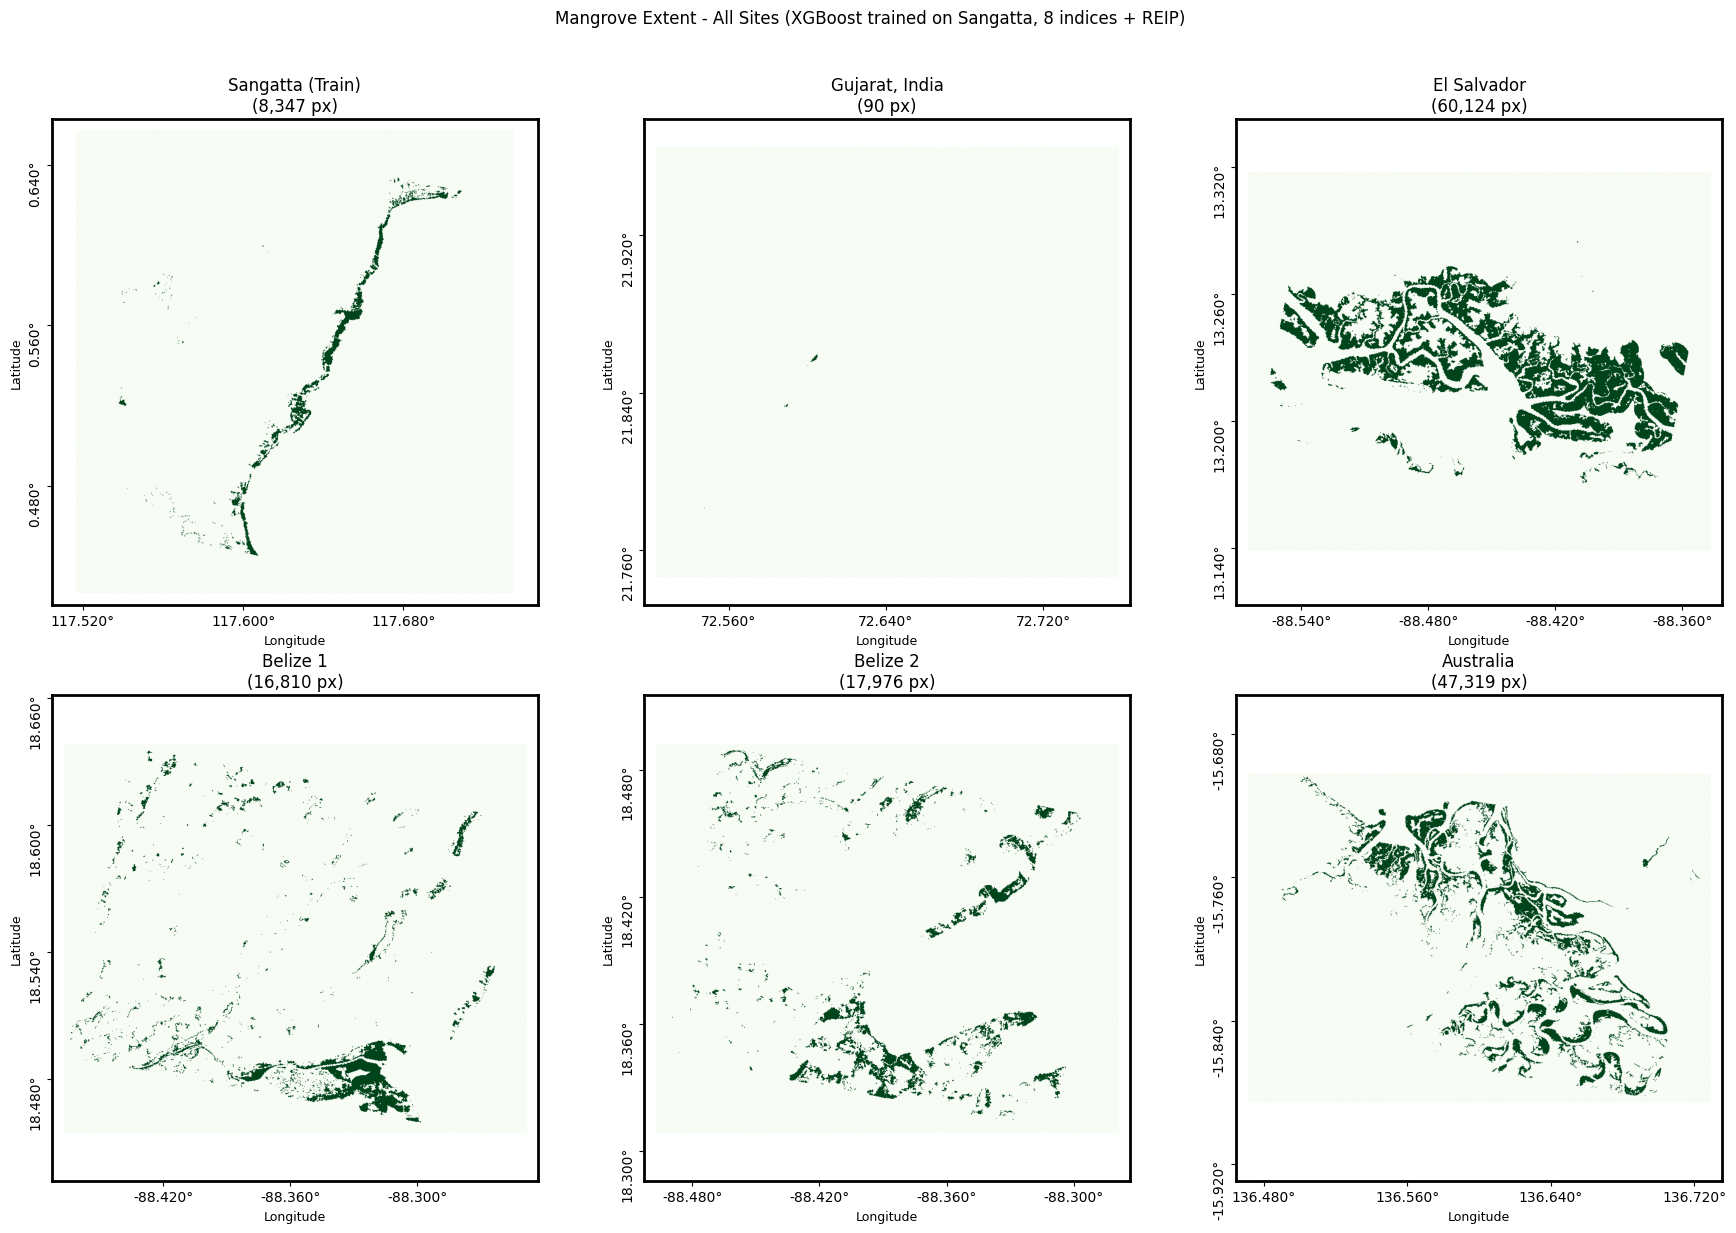

In [9]:
# ============================================================
# Load extent maps - 2x3 grid (matches basemap panel layout)
# Each panel is padded to a square extent so all frames are
# consistently 1:1 regardless of scene aspect or latitude.
# ============================================================
ALL_SITES = [('sangatta', '20250302_030003_92_4001')] + list(TRANSFER_SITES.items())
ALL_LABELS = {'sangatta': 'Sangatta (Train)'}
ALL_LABELS.update(SITE_LABELS)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (site, scene_id) in zip(axes, ALL_SITES):
    extent_path = DATA_PROC / f'extent_mangrove_{site}_{scene_id}.tif'
    if not extent_path.exists():
        ax.text(0.5, 0.5, f'{site}\nnot found',
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        continue
    with rasterio.open(extent_path) as src:
        n_px = int((src.read(1) == 1).sum())
        _img, _ext = reproject_raster_to_4326(src)
    x0, x1, y0, y1 = _ext
    ax.imshow(_img == 1, extent=_ext, origin='upper', cmap='Greens')
    # Pad to square so all panels share a consistent 1:1 frame shape
    mid_x, mid_y = (x0 + x1) / 2, (y0 + y1) / 2
    pad = max(x1 - x0, y1 - y0) / 2 * 1.05
    ax.set_xlim(mid_x - pad, mid_x + pad)
    ax.set_ylim(mid_y - pad, mid_y + pad)
    ax.set_aspect('equal')
    ax.set_title(f'{ALL_LABELS[site]}\n({n_px:,} px)')
    format_map_axes(ax, fontsize=9)

for j in range(len(ALL_SITES), len(axes)):
    axes[j].axis('off')

plt.suptitle('Mangrove Extent - All Sites (XGBoost trained on Sangatta, 8 indices + REIP)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_FIGURES / 'transferability_extent_maps.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Vector Export - Mangrove Extent Polygons

Polygonizes each `extent_mangrove_*.tif` raster to a GeoPackage (one file per site).
Each GPKG contains the dissolved mangrove polygon in the scene's native UTM CRS and is
used as the overlay layer in Section 6.

In [10]:
# ============================================================
# Polygonize extent rasters → GeoPackage (one file per site)
# Dissolves all mangrove polygons per scene into a single feature
# ============================================================
import rasterio.features
from shapely.geometry import shape
import geopandas as gpd

OUT_VECTOR = ROOT / 'outputs' / 'vector'
OUT_VECTOR.mkdir(parents=True, exist_ok=True)

ALL_SITES_VIZ = [('sangatta', '20250302_030003_92_4001')] + list(TRANSFER_SITES.items())
ALL_LABELS_VIZ = {'sangatta': 'Sangatta (Train)'}
ALL_LABELS_VIZ.update(SITE_LABELS)

for site, scene_id in ALL_SITES_VIZ:
    extent_path = DATA_PROC / f'extent_mangrove_{site}_{scene_id}.tif'
    if not extent_path.exists():
        print(f'  {site:<12}: raster not found - skip')
        continue

    with rasterio.open(extent_path) as src:
        img       = src.read(1)
        crs       = src.crs
        transform = src.transform

    mask  = (img == 1).astype('uint8')
    geoms = [
        shape(geom)
        for geom, val in rasterio.features.shapes(
            img.astype('uint8'), mask=mask, transform=transform
        )
        if val == 1
    ]
    if not geoms:
        print(f'  {site:<12}: no mangrove pixels - skip')
        continue

    gdf       = gpd.GeoDataFrame({'geometry': geoms}, crs=crs)
    gdf       = gdf.dissolve().reset_index(drop=True)
    gpkg_path = OUT_VECTOR / f'mangrove_extent_{site}_{scene_id}.gpkg'
    gdf.to_file(gpkg_path, driver='GPKG')

    area_ha = gdf.to_crs(gdf.estimate_utm_crs()).geometry.area.sum() / 1e4
    print(f'  {site:<12}: {len(gdf)} polygon(s)  {area_ha:,.1f} ha  -> {gpkg_path.name}')

print('\nVector export complete.')
print(f'Output directory : {OUT_VECTOR}')

  sangatta    : 1 polygon(s)  751.2 ha  -> mangrove_extent_sangatta_20250302_030003_92_4001.gpkg


  gujarat     : 1 polygon(s)  8.1 ha  -> mangrove_extent_gujarat_20250311_061550_53_4001.gpkg


  elsalvador  : 1 polygon(s)  5,411.2 ha  -> mangrove_extent_elsalvador_20250223_165546_32_4001.gpkg


  belize      : 1 polygon(s)  1,512.9 ha  -> mangrove_extent_belize_20250824_171853_67_4001.gpkg


  belize2     : 1 polygon(s)  1,617.8 ha  -> mangrove_extent_belize2_20250824_171857_84_4001.gpkg
  australia   : 1 polygon(s)  4,258.7 ha  -> mangrove_extent_australia_20250608_014315_58_4001.gpkg

Vector export complete.
Output directory : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/outputs/vector


## 6. Multi-Site Basemap Panel - True Color + Mangrove Extent

3-column x 2-row panel for all 6 sites (row 1: Sangatta, Gujarat, El Salvador;
row 2: Belize 1, Belize 2, Australia). Each panel shows:

- CartoDB Positron basemap (contextily)
- Tanager true-colour composite extracted from the raw HDF5 (R 660 nm, G 560 nm, B 480 nm)
  with 2-98 % percentile contrast stretch; only 3 bands are read from the 426-band cube
- Mangrove extent overlay: purple fill (#9B59B6, 80 % opacity), no stroke
- Scale bar (lower left), north arrow (upper right), legend (lower right)

In [11]:
!pip install contextily

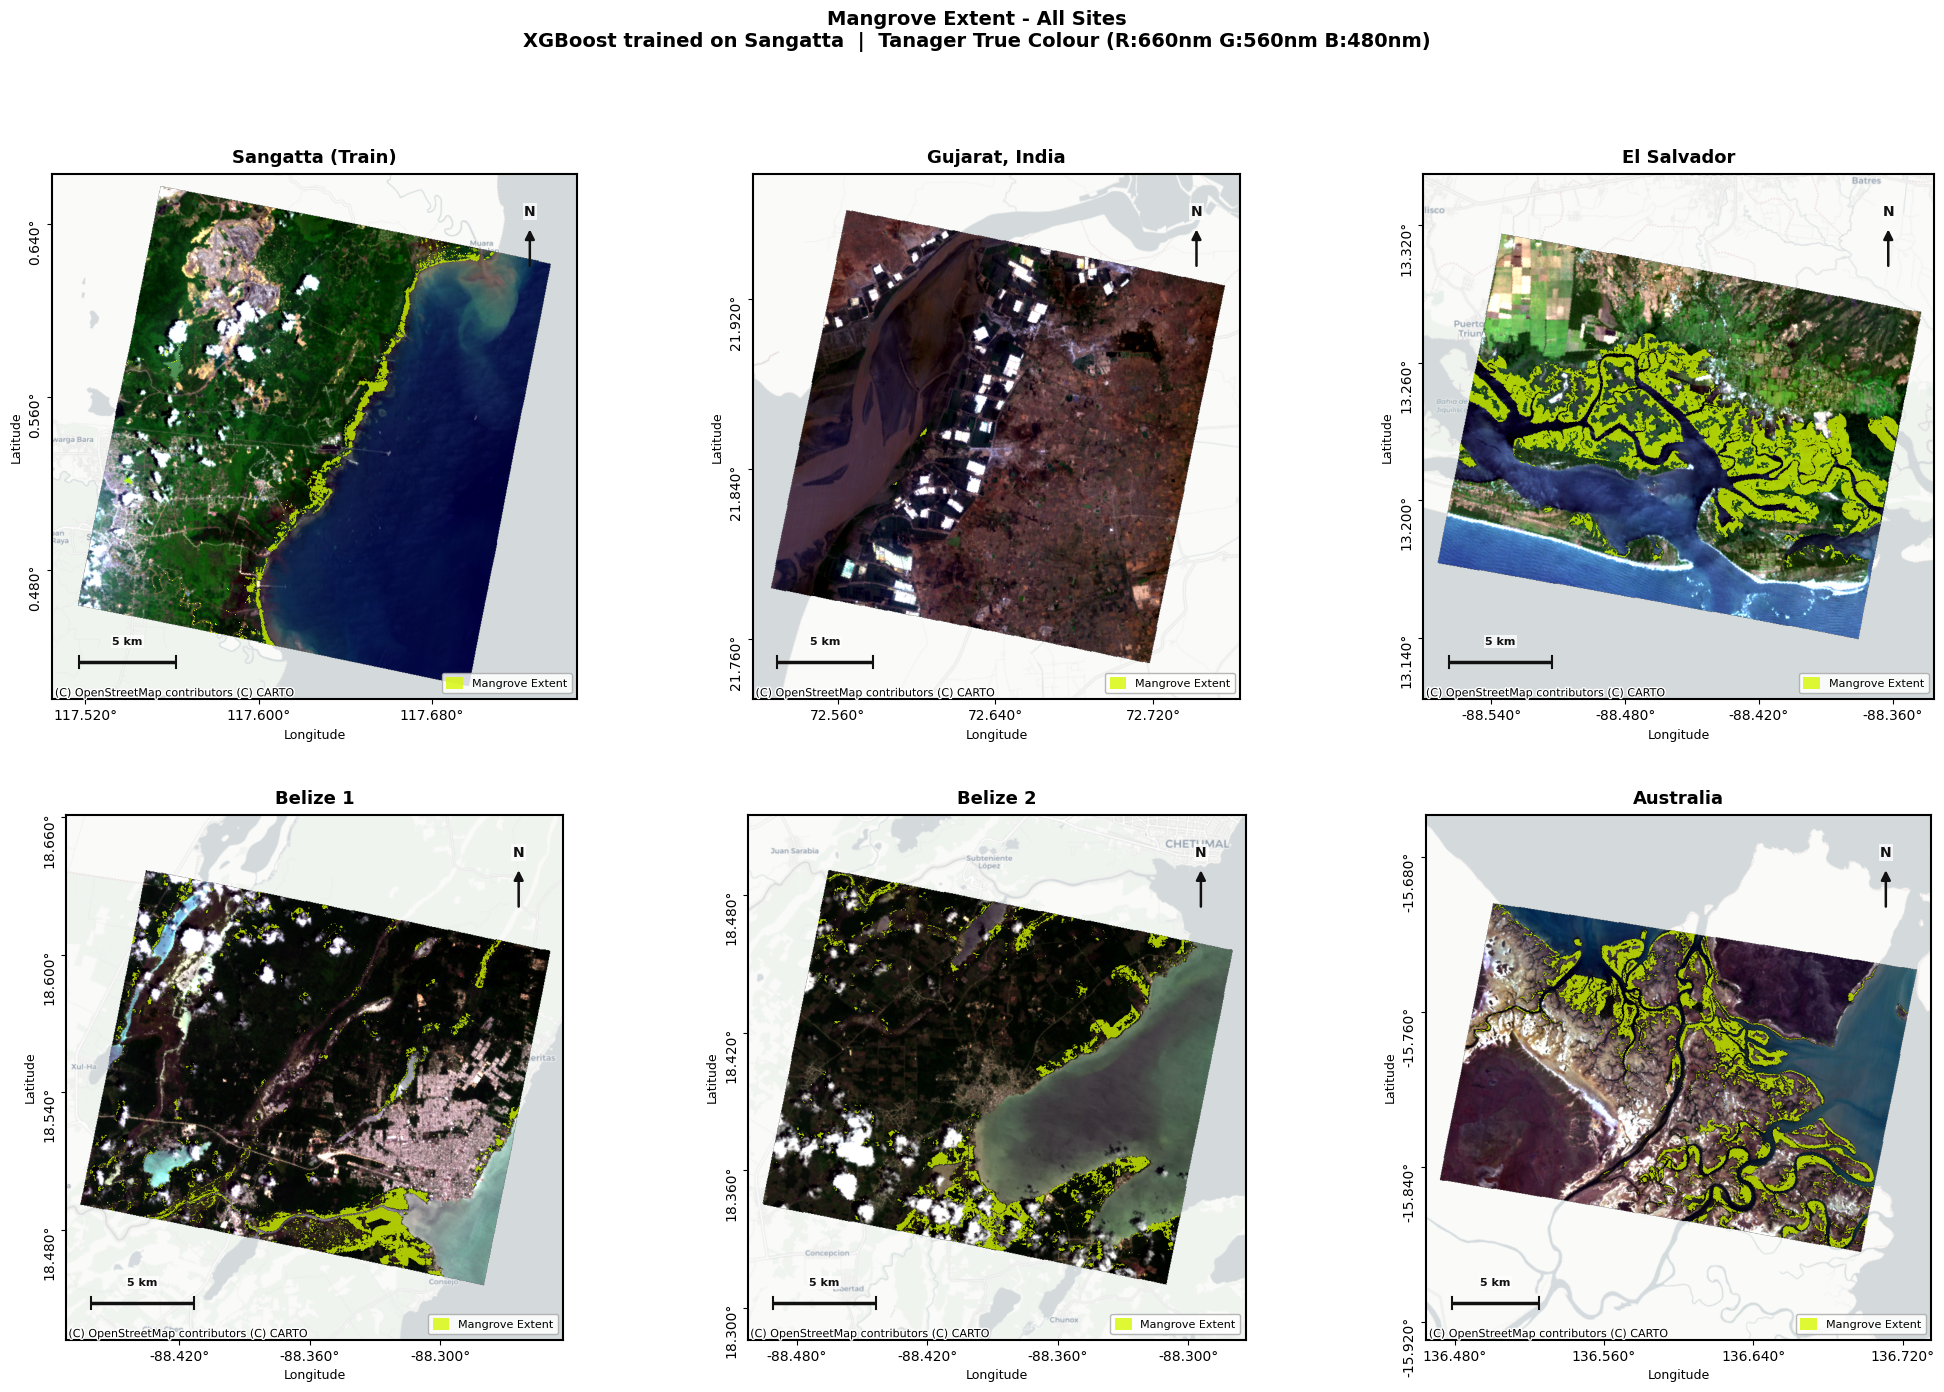

Saved : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/outputs/figures/transferability_basemap_panel.png


In [12]:
# ============================================================
# Helpers
# ============================================================
import os
import re
import h5py
# Unset pyproj PROJ env vars before importing contextily so it uses the system PROJ DB
import os as _os
_os.environ.pop('PROJ_LIB',  None)
_os.environ.pop('PROJ_DATA', None)
import contextily as cx
from affine import Affine
from rasterio.crs import CRS as RasterioCRS
from matplotlib.patches import Patch
import pyproj


def _load_rgb_hdf5(hdf5_path):
    """
    Read blue (480 nm), green (560 nm), red (660 nm) bands from a Tanager HDF5
    without loading the full 426-band cube.  Returns (red, green, blue, crs, transform).
    Nodata pixels (-9999) are replaced with NaN.
    """
    REFL = 'HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance'
    META = 'HDFEOS INFORMATION/StructMetadata.0'
    wl   = np.linspace(380, 2500, 426)
    b_i  = int(np.argmin(np.abs(wl - 480)))
    g_i  = int(np.argmin(np.abs(wl - 560)))
    r_i  = int(np.argmin(np.abs(wl - 660)))

    with h5py.File(hdf5_path, 'r') as f:
        ref   = f[REFL]
        blue  = ref[b_i].astype(np.float32)
        green = ref[g_i].astype(np.float32)
        red   = ref[r_i].astype(np.float32)
        epsg  = int(f['HDFEOS/GRIDS/HYP'].attrs['epsg_code'])
        meta  = f[META][()].decode()

    for band in (blue, green, red):
        band[band <= -9999.0] = np.nan

    ul   = re.search(r'UpperLeftPointMtrs=\(([0-9.\-]+),([0-9.\-]+)\)', meta)
    lr   = re.search(r'LowerRightMtrs=\(([0-9.\-]+),([0-9.\-]+)\)', meta)
    xdim = re.search(r'XDim=(\d+)', meta)
    ul_x, ul_y = float(ul.group(1)), float(ul.group(2))
    pixel      = (float(lr.group(1)) - ul_x) / int(xdim.group(1))
    transform  = Affine(pixel, 0, ul_x, 0, -pixel, ul_y)
    crs        = RasterioCRS.from_wkt(pyproj.CRS.from_epsg(epsg).to_wkt())

    return red, green, blue, crs, transform


def _make_rgba(red, green, blue):
    """Apply 2-98 % contrast stretch; return an (H, W, 4) RGBA float32 array."""
    stacked = np.stack([red, green, blue], axis=-1)
    valid   = ~np.any(np.isnan(stacked), axis=-1)
    rgba    = np.zeros((*stacked.shape[:2], 4), dtype=np.float32)
    for i, band in enumerate([red, green, blue]):
        if np.any(valid):
            vp      = band[valid]
            p2, p98 = np.percentile(vp, [2, 98])
            norm    = (np.clip((band - p2) / (p98 - p2 + 1e-10), 0, 1)
                       if p98 > p2 else np.clip(band, 0, 1))
        else:
            norm = np.clip(band, 0, 1)
        rgba[:, :, i] = np.where(np.isnan(norm), 0.0, norm) * valid
    rgba[:, :, 3] = valid.astype(np.float32)
    return rgba


def _add_scale_bar(ax, fontsize=8):
    """Draw an adaptive scale bar for EPSG:4326 axes (lower-left corner)."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lat_c    = (ylim[0] + ylim[1]) / 2
    width_km = (xlim[1] - xlim[0]) * 111.32 * np.cos(np.radians(lat_c))
    # Pick shortest nice length that is >= 12 % of plot width
    for length_km in [1, 2, 5, 10, 20, 50]:
        if length_km / width_km >= 0.12:
            break
    deg    = length_km / (111.32 * np.cos(np.radians(lat_c)))
    x0     = xlim[0] + (xlim[1] - xlim[0]) * 0.05
    y0     = ylim[0] + (ylim[1] - ylim[0]) * 0.07
    tick_h = (ylim[1] - ylim[0]) * 0.012
    ax.plot([x0, x0 + deg], [y0, y0],
            color='#111', lw=2.5, zorder=10, solid_capstyle='butt')
    for xp in (x0, x0 + deg):
        ax.plot([xp, xp], [y0 - tick_h, y0 + tick_h],
                color='#111', lw=1.5, zorder=10)
    ax.text(x0 + deg / 2, y0 + tick_h * 2.5, f'{length_km} km',
            ha='center', va='bottom', fontsize=fontsize, fontweight='bold',
            color='#111', zorder=10,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1))


def _add_north_arrow(ax, fontsize=10):
    """Draw a north arrow in the upper-right corner."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x  = xlim[0] + (xlim[1] - xlim[0]) * 0.91
    y0 = ylim[0] + (ylim[1] - ylim[0]) * 0.82
    dy = (ylim[1] - ylim[0]) * 0.08
    ax.annotate('', xy=(x, y0 + dy), xytext=(x, y0),
                arrowprops=dict(arrowstyle='-|>', color='#111',
                                lw=1.8, mutation_scale=14),
                zorder=10)
    ax.text(x, y0 + dy + (ylim[1] - ylim[0]) * 0.015, 'N',
            ha='center', va='bottom', fontsize=fontsize, fontweight='bold',
            color='#111', zorder=10,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1))


# ============================================================
# Layout: 3 columns x 2 rows - all 6 sites
# Each panel padded to a square so all frames are consistently 1:1.
# ============================================================
ALL_SITES_VIZ  = [('sangatta', '20250302_030003_92_4001')] + list(TRANSFER_SITES.items())
ALL_LABELS_VIZ = {'sangatta': 'Sangatta (Train)'}
ALL_LABELS_VIZ.update(SITE_LABELS)

OUT_VECTOR = ROOT / 'outputs' / 'vector'

MANGROVE_FILL = '#d7f702'
FILL_ALPHA    = 0.80

fig, axes = plt.subplots(2, 3, figsize=(21, 14))
axes = axes.flatten()

for ax, (site, scene_id) in zip(axes, ALL_SITES_VIZ):
    label     = ALL_LABELS_VIZ.get(site, site)
    hdf5_path = DATA_RAW / f'{site}_{scene_id}_ortho_sr_hdf5.h5'

    if not hdf5_path.exists():
        ax.text(0.5, 0.5, f'{label}\nHDF5 not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.axis('off')
        continue

    # -- True colour from HDF5 (3 bands only) --------------------------
    red, green_b, blue, hdf5_crs, hdf5_tf = _load_rgb_hdf5(str(hdf5_path))
    rgba                                    = _make_rgba(red, green_b, blue)

    _, extent = reproject_array_to_4326(red, hdf5_crs, hdf5_tf)
    reproj_channels = []
    for ch in range(4):
        ch_repr, _ = reproject_array_to_4326(rgba[:, :, ch], hdf5_crs, hdf5_tf)
        reproj_channels.append(ch_repr)
    rgba_repr = np.clip(np.stack(reproj_channels, axis=-1), 0, 1)

    # -- Set axes extent: pad to square so all frames are 1:1 ----------
    x0, x1, y0, y1 = extent
    mid_x, mid_y = (x0 + x1) / 2, (y0 + y1) / 2
    pad = max(x1 - x0, y1 - y0) / 2 * 1.05
    ax.set_xlim(mid_x - pad, mid_x + pad)
    ax.set_ylim(mid_y - pad, mid_y + pad)
    ax.set_aspect('equal')

    # -- Layer 1: CartoDB Positron basemap -----------------------------
    _saved_lib  = os.environ.pop('PROJ_LIB',  None)
    _saved_data = os.environ.pop('PROJ_DATA', None)
    try:
        cx.add_basemap(ax, crs='EPSG:4326',
                       source=cx.providers.CartoDB.Positron,
                       zorder=1, alpha=1.0)
    except Exception as e:
        print(f'  [WARNING] basemap failed for {site}: {e}')
    finally:
        if _saved_lib:  os.environ['PROJ_LIB']  = _saved_lib
        if _saved_data: os.environ['PROJ_DATA'] = _saved_data

    # Re-enforce padded square limits (basemap may shift them)
    ax.set_xlim(mid_x - pad, mid_x + pad)
    ax.set_ylim(mid_y - pad, mid_y + pad)

    # -- Layer 2: Tanager true colour ----------------------------------
    ax.imshow(rgba_repr, extent=extent, origin='upper', zorder=2)

    # -- Layer 3: Mangrove extent polygon (purple fill, no stroke) -----
    gpkg_path = OUT_VECTOR / f'mangrove_extent_{site}_{scene_id}.gpkg'
    if gpkg_path.exists():
        gdf_gcs = gpd.read_file(gpkg_path).to_crs('EPSG:4326')
        gdf_gcs.plot(ax=ax,
                     facecolor=MANGROVE_FILL,
                     edgecolor='none',
                     alpha=FILL_ALPHA,
                     zorder=3)
    else:
        print(f'  [WARNING] GPKG not found for {site} - run Section 5 first')

    # Re-enforce limits after imshow / gdf.plot
    ax.set_xlim(mid_x - pad, mid_x + pad)
    ax.set_ylim(mid_y - pad, mid_y + pad)

    # -- Map elements: legend (lower right), scale bar, north arrow ----
    ax.legend(
        handles=[Patch(facecolor=MANGROVE_FILL, edgecolor='none',
                       alpha=FILL_ALPHA, label='Mangrove Extent')],
        loc='lower right', fontsize=8, framealpha=0.85,
        edgecolor='#aaa', handlelength=1.5, handleheight=1.2,
    )
    _add_scale_bar(ax, fontsize=8)
    _add_north_arrow(ax, fontsize=10)

    ax.set_title(label, fontsize=13, fontweight='bold', pad=8)
    format_map_axes(ax, fontsize=9, spine_color='black', spine_width=1.5)

fig.suptitle(
    'Mangrove Extent - All Sites\n'
    'XGBoost trained on Sangatta  |  '
    'Tanager True Colour (R:660nm G:560nm B:480nm)',
    fontsize=14, fontweight='bold', y=1.01,
)
fig.tight_layout(pad=3.0, h_pad=3.5, w_pad=3.0)

out_png = OUT_FIGURES / 'transferability_basemap_panel.png'
plt.savefig(out_png, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved : {out_png}')

## 7. Commission-Omission Error Panel -- All Sites

Per-pixel agreement between the XGBoost extent map and GMW v3 for all 6 sites.
Same 3x2 layout and CartoDB Positron basemap as Section 6.

- **Green**  = TP (correct mangrove -- both model and GMW agree)
- **Red**    = FP (commission error -- model predicts mangrove, GMW says no)
- **Orange** = FN (omission error -- GMW says mangrove, model misses it)

  GMW v3 rasterized : 13,522 mangrove px (1.96%)
  GMW v3 rasterized : 3,849 mangrove px (0.61%)
  GMW v3 rasterized : 98,825 mangrove px (19.22%)
  GMW v3 rasterized : 30,407 mangrove px (5.93%)
  GMW v3 rasterized : 8,005 mangrove px (1.56%)
  GMW v3 rasterized : 64,478 mangrove px (10.56%)


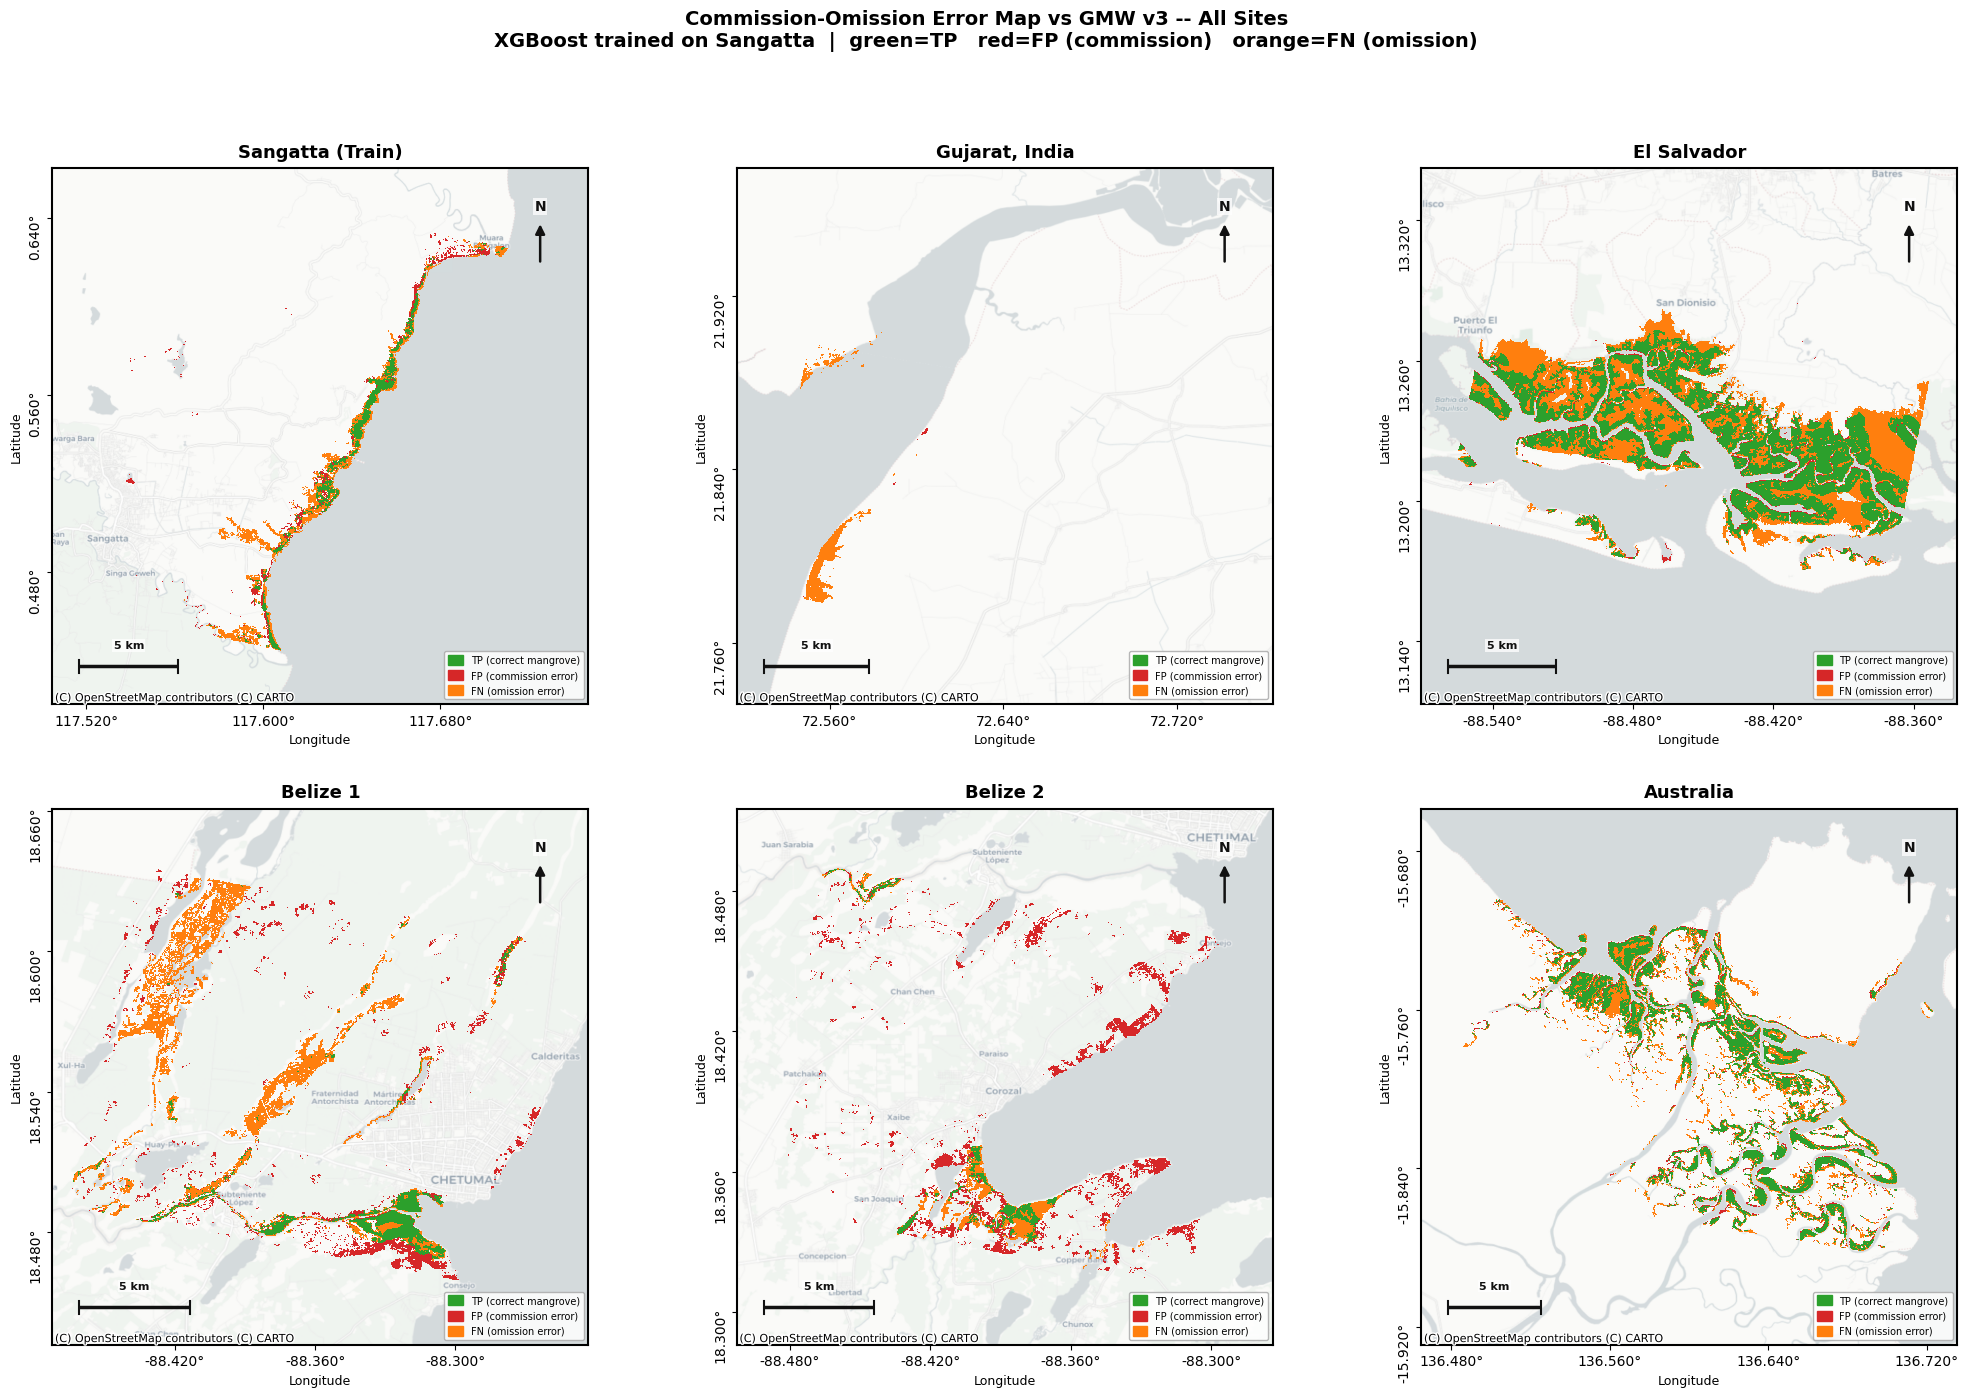

Saved : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/outputs/figures/commission_omission_panel.png


In [14]:
# ============================================================
# Commission-omission error panel -- all 6 sites
# green=TP  red=FP (commission)  orange=FN (omission)
# Background pixels (value 0) are fully transparent -- basemap shows through.
# ============================================================
from matplotlib.colors import ListedColormap, BoundaryNorm
from src.evaluation import build_agree_array, rasterize_gmw

# 3-color map: 1=TP green, 2=FP red, 3=FN orange; 0=background (masked, alpha=0)
_cmap_agree = ListedColormap(['#2ca02c', '#d62728', '#ff7f0e'])
_cmap_agree.set_bad(alpha=0)
_norm_agree = BoundaryNorm([1, 2, 3, 4], ncolors=3)

fig, axes = plt.subplots(2, 3, figsize=(21, 14))
axes = axes.flatten()

for ax, (site, scene_id) in zip(axes, ALL_SITES_VIZ):
    label     = ALL_LABELS_VIZ.get(site, site)
    ext_path  = DATA_PROC / f'extent_mangrove_{site}_{scene_id}.tif'
    gmw_path  = DATA_GMW  / f'gmw_{site}_{scene_id}.geojson'

    if not ext_path.exists():
        ax.text(0.5, 0.5, f'{label}\nextent TIF not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.axis('off')
        continue

    # -- Load extent raster ----------------------------------------
    with rasterio.open(str(ext_path)) as src:
        extent_map = src.read(1)
        ext_crs    = src.crs
        ext_tf     = src.transform
        ref_shape  = extent_map.shape

    # -- Build agreement array -------------------------------------
    if gmw_path.exists():
        gmw_raster = rasterize_gmw(str(gmw_path), ref_shape, ext_tf, ext_crs)
        agree      = build_agree_array(extent_map, gmw_raster)
    else:
        print(f'  [WARNING] GMW not found for {site} -- TP/FP/FN unavailable')
        agree = (extent_map == 1).astype('uint8')

    # -- Reproject to EPSG:4326 (nearest -- values stay exactly 0/1/2/3) --
    agree_img, extent = reproject_array_to_4326(
        agree.astype(np.float32), ext_crs, ext_tf
    )

    # -- Mask background (value 0) so basemap shows through --------
    agree_masked = np.ma.masked_where(agree_img == 0, agree_img)

    # -- Set axes extent: square-padded 1:1 -----------------------
    x0, x1, y0, y1 = extent
    mid_x, mid_y   = (x0 + x1) / 2, (y0 + y1) / 2
    pad = max(x1 - x0, y1 - y0) / 2 * 1.05
    ax.set_xlim(mid_x - pad, mid_x + pad)
    ax.set_ylim(mid_y - pad, mid_y + pad)
    ax.set_aspect('equal')

    # -- Layer 1: CartoDB Positron basemap -------------------------
    _saved_lib  = os.environ.pop('PROJ_LIB',  None)
    _saved_data = os.environ.pop('PROJ_DATA', None)
    try:
        cx.add_basemap(ax, crs='EPSG:4326',
                       source=cx.providers.CartoDB.Positron,
                       zorder=1, alpha=1.0)
    except Exception as e:
        print(f'  [WARNING] basemap failed for {site}: {e}')
    finally:
        if _saved_lib:  os.environ['PROJ_LIB']  = _saved_lib
        if _saved_data: os.environ['PROJ_DATA'] = _saved_data

    ax.set_xlim(mid_x - pad, mid_x + pad)
    ax.set_ylim(mid_y - pad, mid_y + pad)

    # -- Layer 2: Agreement overlay (transparent where value == 0) -
    ax.imshow(agree_masked, cmap=_cmap_agree, norm=_norm_agree,
              extent=extent, origin='upper', zorder=2, interpolation='none')

    # Re-enforce square limits after imshow
    ax.set_xlim(mid_x - pad, mid_x + pad)
    ax.set_ylim(mid_y - pad, mid_y + pad)

    # -- Map elements ----------------------------------------------
    ax.legend(
        handles=[
            Patch(color='#2ca02c', label='TP (correct mangrove)'),
            Patch(color='#d62728', label='FP (commission error)'),
            Patch(color='#ff7f0e', label='FN (omission error)'),
        ],
        loc='lower right', fontsize=7, framealpha=0.85,
        edgecolor='#aaa', handlelength=1.5, handleheight=1.2,
    )
    _add_scale_bar(ax, fontsize=8)
    _add_north_arrow(ax, fontsize=10)

    ax.set_title(label, fontsize=13, fontweight='bold', pad=8)
    format_map_axes(ax, fontsize=9, spine_color='black', spine_width=1.5)

fig.suptitle(
    'Commission-Omission Error Map vs GMW v3 -- All Sites\n'
    'XGBoost trained on Sangatta  |  '
    'green=TP   red=FP (commission)   orange=FN (omission)',
    fontsize=14, fontweight='bold', y=1.01,
)
fig.tight_layout(pad=3.0, h_pad=3.5, w_pad=3.0)

out_png = OUT_FIGURES / 'commission_omission_panel.png'
plt.savefig(out_png, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved : {out_png}')